In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('retail_store.csv')

In [3]:
df

,BillNo,Customer,Product,Quantity,Price,TotalBill,PaymentMode
0,3001,Cust_1,Sugar,1,1349,1349,UPI
1,3002,Cust_2,Soap,1,1298,1298,Cash
2,3003,Cust_3,Sugar,4,983,3932,Card
3,3004,Cust_4,Rice,6,1946,11676,Cash
4,3005,Cust_5,Sugar,2,848,1696,Cash
...,...,...,...,...,...,...,...
95,3096,Cust_96,Rice,6,666,3996,Card
96,3097,Cust_97,Sugar,7,1480,10360,Card
97,3098,Cust_98,Sugar,5,536,2680,Card
98,3099,Cust_99,Milk,7,754,5278,Cash


In [4]:
df.shape

(100, 7)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   BillNo       100 non-null    int64
 1   Customer     100 non-null    str  
 2   Product      100 non-null    str  
 3   Quantity     100 non-null    int64
 4   Price        100 non-null    int64
 5   TotalBill    100 non-null    int64
 6   PaymentMode  100 non-null    str  
dtypes: int64(4), str(3)
memory usage: 5.6 KB


# NUMPY

In [6]:
np.sum(df['Price'])

np.int64(98413)

In [7]:
df['BillNo'].shape[0]  # to count rows

100

In [8]:
df['BillNo'].nunique()  # to count values unique in a row

100

In [9]:
np.average(df['TotalBill'])

np.float64(4365.65)

In [10]:
np.max(df['TotalBill'])

np.int64(13601)

# PANDAS

In [11]:
df.sample(5)

,BillNo,Customer,Product,Quantity,Price,TotalBill,PaymentMode
71,3072,Cust_72,Milk,1,854,854,Card
37,3038,Cust_38,Soap,4,1593,6372,Cash
54,3055,Cust_55,Sugar,7,812,5684,Card
77,3078,Cust_78,Soap,2,1132,2264,Card
45,3046,Cust_46,Soap,4,501,2004,Cash


In [23]:
df['Product'].value_counts()

Product
Sugar    22
Milk     22
Oil      20
Soap     18
Rice     18
Name: count, dtype: int64

In [12]:
df.groupby('Product')['TotalBill'].sum().sort_values(ascending=False)

Product
Milk     106505
Rice      98497
Oil       95294
Sugar     90866
Soap      45403
Name: TotalBill, dtype: int64

In [24]:
df.groupby('PaymentMode')['BillNo'].count()

PaymentMode
Card    40
Cash    26
UPI     34
Name: BillNo, dtype: int64

In [25]:
df['PaymentMode'].value_counts()

PaymentMode
Card    40
UPI     34
Cash    26
Name: count, dtype: int64

In [14]:
df['TotalBill']>5000

0     False
1     False
2     False
3      True
4     False
      ...  
95    False
96     True
97    False
98     True
99     True
Name: TotalBill, Length: 100, dtype: bool

In [15]:
df.loc[df['TotalBill'] > 5000, ['Customer', 'TotalBill']].head()

,Customer,TotalBill
3,Cust_4,11676
6,Cust_7,9430
7,Cust_8,8715
10,Cust_11,7707
11,Cust_12,5208


In [16]:
df.loc[df['TotalBill'] > 5000].shape[0]

41

In [17]:
df['Product'].value_counts().head(5)
# https://copilot.microsoft.com/shares/DW5PkqNp3R5DoKSNzwEEK check this

Product
Sugar    22
Milk     22
Oil      20
Soap     18
Rice     18
Name: count, dtype: int64

# MATPLOTLIB

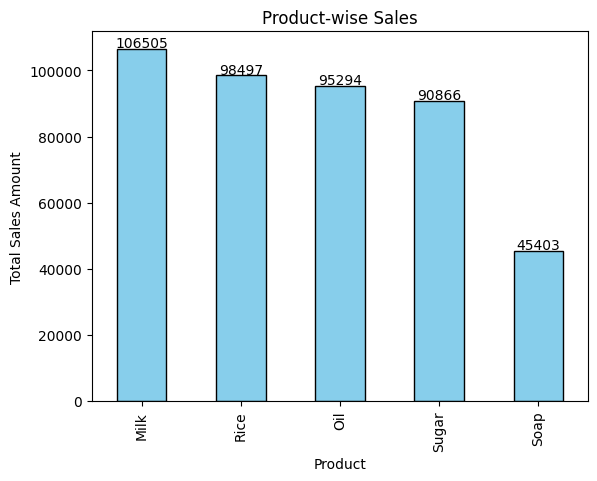

In [28]:
import matplotlib.pyplot as plt

# Group by product and sum the sales
product_sales = df.groupby('Product')['TotalBill'].sum().sort_values(ascending=False)

# Plot bar chart
product_sales.plot(kind='bar', color='skyblue', edgecolor='black')

# Add labels and title
plt.xlabel('Product')
plt.ylabel('Total Sales Amount')
plt.title('Product-wise Sales')

# Add values on top of bars
for i, value in enumerate(product_sales.values):
    plt.text(i, value + 500, str(value), ha='center', rotation=0)

plt.show()

# https://copilot.microsoft.com/shares/wtiL7LkrLbgyq55r9fwrD

# https://copilot.microsoft.com/shares/YKQ7zkFttWPY2dfC88dE2


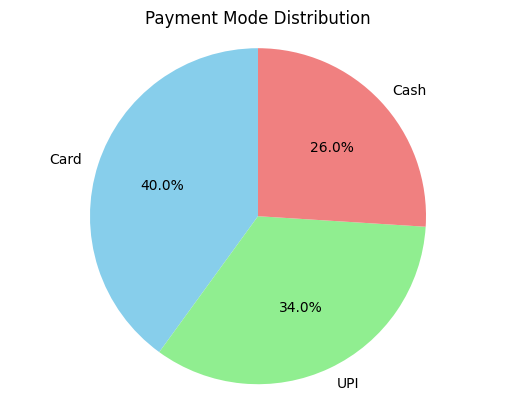

In [19]:
import matplotlib.pyplot as plt

# Count payment modes
payment_counts = df['PaymentMode'].value_counts()

# Plot pie chart
payment_counts.plot(
    kind='pie',
    autopct='%1.1f%%',   # show percentages
    startangle=90,       # rotate chart for better look
    colors=['skyblue', 'lightgreen', 'lightcoral', 'gold']  # optional styling
)

# Add title
plt.title('Payment Mode Distribution')

# Equal aspect ratio ensures pie is drawn as a circle
plt.axis('equal')


plt.show()
# https://copilot.microsoft.com/shares/F6hhX3DuUxPrkduikmsd9 

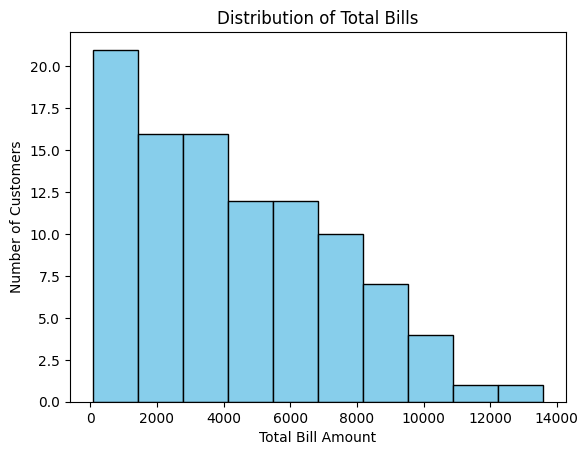

In [20]:
import matplotlib.pyplot as plt

# Histogram of TotalBill column
plt.hist(df['TotalBill'], bins=10, edgecolor='black', color='skyblue')

# Add labels and title
plt.xlabel('Total Bill Amount')
plt.ylabel('Number of Customers')
plt.title('Distribution of Total Bills')

plt.show()
